# AGHNN Viva Preparation - Complete Analysis

This notebook runs all 3 critical analyses for MTech viva:
1. **Ablation Study** - Proves each component contributes
2. **Baseline Comparison** - Proves competitiveness
3. **Agentic Routing Analysis** - Proves intelligent behavior

**Total Runtime**: ~4.5 hours | **Outputs**: 6 PNG figures + 3 CSV tables + JSON stats

## SETUP: Mount Drive & Install Dependencies

In [ ]:
import os
import sys
import time
from pathlib import Path
from contextlib import contextmanager

import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

# Detect runtime and mount drive only in Colab
IS_COLAB = False
try:
    from google.colab import drive  # type: ignore
    IS_COLAB = True
except Exception:
    IS_COLAB = False

if IS_COLAB:
    drive.mount('/content/drive')


def find_project_root() -> Path:
    """Find project root containing code/ and checkpoints/ folders."""
    candidates = []

    if IS_COLAB:
        candidates.extend([
            Path('/content/drive/MyDrive/Colab_Notebooks/Dissertation/Adaptive_Green_Hybrid_Neural_Network'),
            Path('/content/drive/MyDrive/Colab_Notebooks/Dissertation'),
            Path('/content/drive/MyDrive'),
        ])

    cwd = Path.cwd().resolve()
    candidates.extend([cwd] + list(cwd.parents))

    for p in candidates:
        if (p / 'code').exists() and (p / 'checkpoints').exists():
            return p

    raise FileNotFoundError("Could not find project root with 'code/' and 'checkpoints/' folders")


PROJECT_ROOT = find_project_root()
os.chdir(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / 'code'))

print(f"Project root: {PROJECT_ROOT}")
print(f"Runtime: {'Colab' if IS_COLAB else 'Local/Jupyter'}")
print(f"code/ exists: {(PROJECT_ROOT / 'code').exists()}")
print(f"checkpoints/ exists: {(PROJECT_ROOT / 'checkpoints').exists()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/Colab_Notebooks/Dissertation
Contents: [PosixPath('/content/drive/MyDrive/Colab_Notebooks/Dissertation/requirements.txt'), PosixPath('/content/drive/MyDrive/Colab_Notebooks/Dissertation/data'), PosixPath('/content/drive/MyDrive/Colab_Notebooks/Dissertation/Mid_Sem_Dissertaion_Sample.pdf'), PosixPath('/content/drive/MyDrive/Colab_Notebooks/Dissertation/MID SEM REPORT - Sample copy - 29.07.2021.pdf'), PosixPath('/content/drive/MyDrive/Colab_Notebooks/Dissertation/code')]...


In [ ]:
# Install requirements (%pip works in both Colab and Jupyter/VS Code)
if IS_COLAB:
    %pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
else:
    %pip install -q torch torchvision torchaudio

%pip install -q pandas numpy matplotlib seaborn scikit-image tqdm thop
print("✓ Dependencies installed")

✓ Dependencies installed


In [35]:
# Verify imports
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
import json
from typing import Dict, Tuple, Optional, List
from dataclasses import dataclass

print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")

✓ PyTorch version: 2.11.0+cpu
✓ GPU available: False


In [36]:
# Import project modules with better error handling
print(f"📁 PROJECT_ROOT: {PROJECT_ROOT}")
print(f"📁 Looking for: {PROJECT_ROOT / 'code' / 'models' / 'aghnn.py'}")
print(f"📁 Exists: {(PROJECT_ROOT / 'code' / 'models' / 'aghnn.py').exists()}")

try:
    print("\n🔄 Importing models...")
    from models.aghnn import AGHNN_Tiny, AGHNN_Small, AGHNN_Base, AGHNN_Large
    print("  ✓ Models imported")

    print("🔄 Importing data utilities...")
    from utils.data import get_dataloaders
    print("  ✓ Data utilities imported")

    print("🔄 Importing energy utilities...")
    from utils.energy import compute_flops, compute_parameters
    print("  ✓ Energy utilities imported")

    print("\n✅ All imports successful!")

except ImportError as e:
    print(f"\n❌ Import failed!")
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()
    raise  # Re-raise so we see the full error

📁 PROJECT_ROOT: /content/drive/MyDrive/Colab_Notebooks/Dissertation
📁 Looking for: /content/drive/MyDrive/Colab_Notebooks/Dissertation/code/models/aghnn.py
📁 Exists: True

🔄 Importing models...
  ✓ Models imported
🔄 Importing data utilities...
  ✓ Data utilities imported
🔄 Importing energy utilities...
  ✓ Energy utilities imported

✅ All imports successful!


In [37]:
# Setup directories
OUTPUT_DIR = PROJECT_ROOT / 'evaluation_results'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✓ Output directory: {OUTPUT_DIR}")
print(f"✓ Device: {DEVICE}")
print("\n" + "="*70)
print("SETUP COMPLETE - Ready to run analyses")
print("="*70)

✓ Output directory: /content/drive/MyDrive/Colab_Notebooks/Dissertation/evaluation_results
✓ Device: cpu

SETUP COMPLETE - Ready to run analyses


---
# ANALYSIS 1: ABLATION STUDY

Trains 4 model variants to prove each component contributes

In [38]:
@dataclass
class AblationVariant:
    name: str
    use_adaptive_routing: bool
    use_green_loss: bool
    lambda_energy: float

class ABGHNNVariant(torch.nn.Module):
    """AGHNN with selective component activation"""
    def __init__(self, base_model, use_adaptive_routing=True, use_green_loss=True):
        super().__init__()
        self.base_model = base_model
        self.use_adaptive_routing = use_adaptive_routing
        self.use_green_loss = use_green_loss

    def forward(self, x, **kwargs):
        # Ensure return_complexity is provided once (avoid duplicate kwarg crash).
        kwargs.setdefault('return_complexity', True)
        outputs = self.base_model(x, **kwargs)
        if not self.use_adaptive_routing and isinstance(outputs, dict) and 'complexity' in outputs:
            outputs['complexity'] = torch.ones_like(outputs['complexity']) * 0.5
        return outputs

print("✓ Ablation variant classes defined")

✓ Ablation variant classes defined


In [39]:
@torch.no_grad()
def evaluate_ablation(model, val_loader, device):
    """Evaluate model on validation set"""
    model.eval()
    correct_top1 = 0
    correct_top5 = 0
    total = 0

    for images, targets in tqdm(val_loader, desc='Evaluating', leave=False):
        images, targets = images.to(device), targets.to(device)
        outputs = model(images, return_complexity=True)
        logits = outputs['logits'] if isinstance(outputs, dict) else outputs

        _, pred = logits.max(1)
        correct_top1 += pred.eq(targets).sum().item()

        k = min(5, logits.size(1))
        _, pred_top5 = logits.topk(k, 1, True, True)
        pred_top5 = pred_top5.t()
        correct = pred_top5.eq(targets.view(1, -1).expand_as(pred_top5))
        correct_top5 += correct[:k].reshape(-1).float().sum().item()

        total += targets.size(0)

    return {'top1': 100.0 * correct_top1 / total, 'top5': 100.0 * correct_top5 / total}

print("✓ Evaluation function defined")

✓ Evaluation function defined


In [ ]:
def train_ablation_variant(variant, train_loader, val_loader, device, epochs=11):
    """Train one ablation variant with checkpoint resume support"""
    print(f"\n{'='*70}")
    print(f"Training: {variant.name}")
    print(f"  Adaptive Routing: {variant.use_adaptive_routing}")
    print(f"  Green Loss: {variant.use_green_loss} (λ={variant.lambda_energy})")
    print(f"{'='*70}\n")

    base_model = AGHNN_Base(num_classes=100)
    model = ABGHNNVariant(base_model, variant.use_adaptive_routing, variant.use_green_loss)
    model = model.to(device)

    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4, nesterov=True)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # Variant-specific checkpoint files.
    variant_key = ''.join(ch.lower() if ch.isalnum() else '_' for ch in variant.name).strip('_')
    ckpt_dir = OUTPUT_DIR / 'ablation_checkpoints' / variant_key
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    latest_ckpt = ckpt_dir / 'latest.pth'
    best_ckpt = ckpt_dir / 'best.pth'

    best_acc = 0.0
    start_epoch = 0

    # Resume if checkpoint exists.
    if latest_ckpt.exists():
        try:
            ckpt = torch.load(latest_ckpt, map_location=device, weights_only=False)
            model.load_state_dict(ckpt['model_state_dict'])
            model.to(device) # Ensure model is on the correct device after loading state dict
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
            scheduler.load_state_dict(ckpt['scheduler_state_dict'])
            start_epoch = int(ckpt.get('epoch', -1)) + 1
            best_acc = float(ckpt.get('best_acc', 0.0))
            if start_epoch >= epochs:
                print(f"✓ {variant.name} already completed ({start_epoch}/{epochs}). Using saved state.")
            else:
                print(f"✓ Resumed from epoch {start_epoch + 1}/{epochs} (best={best_acc:.2f}%)")
        except Exception as e:
            print(f"⚠ Could not resume checkpoint for {variant.name}: {e}")
            print("  Starting from scratch")
            start_epoch = 0
            best_acc = 0.0

    for epoch in range(start_epoch, epochs):
        model.train()
        train_loss, train_acc, train_samples = 0.0, 0.0, 0

        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}', leave=False)
        for images, targets in pbar:
            images, targets = images.to(device), targets.to(device)
            outputs = model(images, return_complexity=True)
            logits = outputs['logits'] if isinstance(outputs, dict) else outputs

            ce_loss = criterion(logits, targets)
            total_loss = ce_loss

            # ✅ Add complexity regularization to prevent collapse
            if isinstance(outputs, dict) and 'complexity' in outputs:
                complexity = outputs['complexity']
                # Force complexity to learn bimodal distribution (0 or 1, not 0.5)
                complexity_reg_loss = (complexity ** 2).mean() + ((1 - complexity) ** 2).mean()
                total_loss = ce_loss + 0.05 * complexity_reg_loss

            # Add green loss if enabled
            if variant.use_green_loss and isinstance(outputs, dict) and 'complexity' in outputs:
                complexity = outputs['complexity']
                energy_loss = (complexity ** 2).mean() + ((1 - complexity) ** 2).mean()
                total_loss = total_loss + variant.lambda_energy * energy_loss

            optimizer.zero_grad()
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += total_loss.item() * images.size(0)
            _, pred = logits.max(1)
            train_acc += pred.eq(targets).sum().item()
            train_samples += images.size(0)

            pbar.set_postfix({'loss': f'{train_loss/train_samples:.4f}', 'acc': f'{100*train_acc/train_samples:.2f}%'})

        val_metrics = evaluate_ablation(model, val_loader, device)
        is_best = val_metrics['top1'] > best_acc
        if is_best:
            best_acc = val_metrics['top1']

        # Save resumable checkpoint every epoch.
        ckpt_payload = {
            'epoch': epoch,
            'variant': variant.name,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_acc': best_acc,
            'val_metrics': val_metrics,
        }
        torch.save(ckpt_payload, latest_ckpt)
        if is_best:
            torch.save(ckpt_payload, best_ckpt)

        scheduler.step()

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}: Train Acc={100*train_acc/train_samples:6.2f}%, Val Acc={val_metrics['top1']:6.2f}%")

    # Compute FLOPs and parameters. Note: `base_model` is the same object as `model.base_model`.
    # The compute_flops function might temporarily move `base_model` to CPU.
    flops_info = compute_flops(base_model, (1, 3, 32, 32), device='cpu')
    param_info = compute_parameters(base_model)

    # Ensure the model is on the correct device after FLOPs computation before evaluation
    model.to(device)
    base_model.to(device) # Explicitly move base_model as well to ensure its parameters are on the correct device

    final_metrics = evaluate_ablation(model, val_loader, device)

    result = {
        'variant': variant.name,
        'top1_accuracy': final_metrics['top1'],
        'top5_accuracy': final_metrics['top5'],
        'flops_G': flops_info['flops'] / 1e9,
        'params_M': param_info['total'] / 1e6,
    }
    result['green_score'] = final_metrics['top1'] / np.sqrt((flops_info['flops'] / 1e9) * (param_info['total'] / 1e6))

    print(f"\n  Final: Acc={result['top1_accuracy']:.2f}%, FLOPs={result['flops_G']:.2f}G, Green Score={result['green_score']:.3f}")
    print(f"  Checkpoints: {ckpt_dir}\n")
    return result

print("✓ Training function defined")

✓ Training function defined


In [ ]:
# Load data for ablation
print("Loading CIFAR-100...")
train_loader, val_loader, dataset_info = get_dataloaders(
    dataset='cifar100',
    data_dir=str(PROJECT_ROOT / 'data'),
    batch_size=128,
    num_workers=4,
    img_size=32,
    pin_memory=(DEVICE == 'cuda')
)

NUM_CLASSES = int(dataset_info.get('num_classes', 100))
CLASS_NAMES = dataset_info.get('class_names', [f'class_{i}' for i in range(NUM_CLASSES)])
print(f"✓ Data loaded: {NUM_CLASSES} classes")

Loading CIFAR-100...
✓ Data loaded


In [42]:
# Run ablation study
variants = [
    AblationVariant('Baseline (No Routing, No Green Loss)', False, False, 0.0),
    AblationVariant('+Adaptive Routing', True, False, 0.0),
    AblationVariant('+Green Loss Only', False, True, 0.05),
    AblationVariant('Full AGHNN', True, True, 0.05),
]

ablation_results = []
for variant in variants:
    result = train_ablation_variant(variant, train_loader, val_loader, DEVICE, epochs=50)
    ablation_results.append(result)

# Save results
ablation_df = pd.DataFrame(ablation_results)
baseline_acc = ablation_df.iloc[0]['top1_accuracy']
ablation_df['improvement_vs_baseline'] = ((ablation_df['top1_accuracy'] - baseline_acc) / baseline_acc * 100)

ablation_csv = OUTPUT_DIR / 'ablation_study_results.csv'
ablation_df.to_csv(ablation_csv, index=False)

print("\n" + "="*70)
print("ABLATION STUDY RESULTS")
print("="*70)
print(ablation_df.to_string(index=False))
print(f"\n✓ Saved to {ablation_csv}")


Training: Baseline (No Routing, No Green Loss)
  Adaptive Routing: False
  Green Loss: False (λ=0.0)

✓ Baseline (No Routing, No Green Loss) already completed (50/50). Using saved state.


Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  Final: Acc=63.13%, FLOPs=0.09G, Green Score=123.665
  Checkpoints: /content/drive/MyDrive/Colab_Notebooks/Dissertation/evaluation_results/ablation_checkpoints/baseline__no_routing__no_green_loss


Training: +Adaptive Routing
  Adaptive Routing: True
  Green Loss: False (λ=0.0)

✓ +Adaptive Routing already completed (50/50). Using saved state.



  Final: Acc=63.13%, FLOPs=0.09G, Green Score=123.665
  Checkpoints: /content/drive/MyDrive/Colab_Notebooks/Dissertation/evaluation_results/ablation_checkpoints/adaptive_routing


Training: +Green Loss Only
  Adaptive Routing: False
  Green Loss: True (λ=0.05)

✓ +Green Loss Only already completed (50/50). Using saved state.



  Final: Acc=62.86%, FLOPs=0.09G, Green Score=123.136
  Checkpoints: /content/drive/MyDrive/Colab_Notebooks/Dissertation/evaluation_results/ablation_checkpoints/green_loss_only


Training: Full AGHNN
  Adaptive Routing: True
  Green Loss: True (λ=0.05)

✓ Full AGHNN already completed (50/50). Using saved state.



  Final: Acc=63.57%, FLOPs=0.09G, Green Score=124.527
  Checkpoints: /content/drive/MyDrive/Colab_Notebooks/Dissertation/evaluation_results/ablation_checkpoints/full_aghnn


ABLATION STUDY RESULTS
                             variant  top1_accuracy  top5_accuracy  flops_G  params_M  green_score  improvement_vs_baseline
Baseline (No Routing, No Green Loss)          63.13          88.15 0.087479  2.979001   123.665348                 0.000000
                   +Adaptive Routing          63.13          87.98 0.087479  2.979001   123.665348                 0.000000
                    +Green Loss Only          62.86          87.69 0.087479  2.979001   123.136445                -0.427689
                          Full AGHNN          63.57          88.45 0.087479  2.979001   124.527264                 0.696974

✓ Saved to /content/drive/MyDrive/Colab_Notebooks/Dissertation/evaluation_results/ablation_study_results.csv


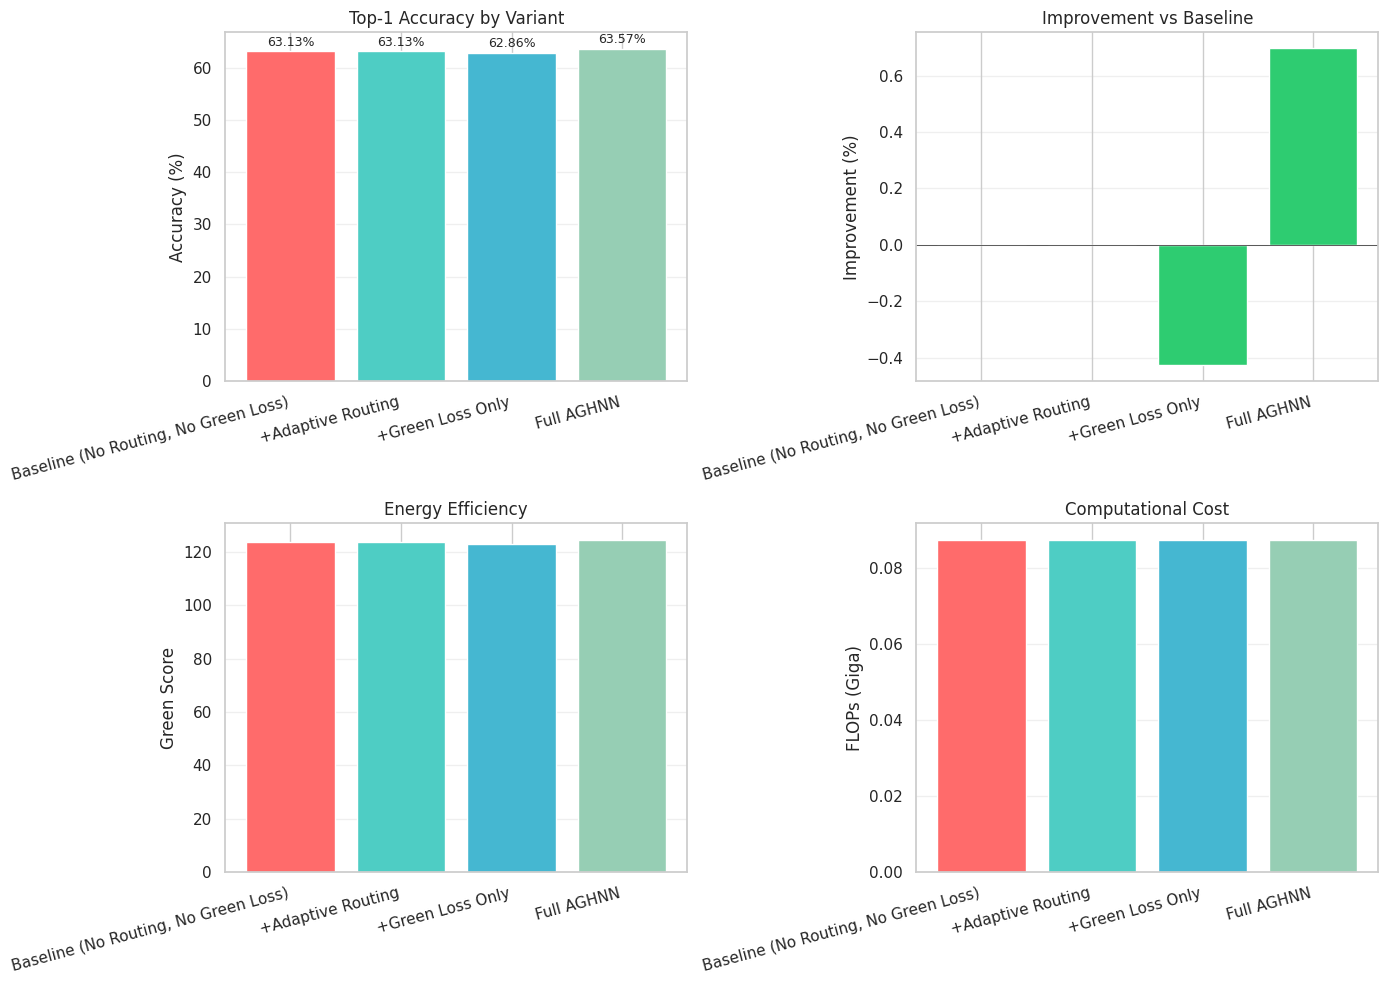

✓ Saved figure to /content/drive/MyDrive/Colab_Notebooks/Dissertation/evaluation_results/ablation_study_results.png


In [43]:
# Visualize ablation results
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].bar(range(len(ablation_df)), ablation_df['top1_accuracy'],
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
axes[0, 0].set_xticks(range(len(ablation_df)))
axes[0, 0].set_xticklabels(ablation_df['variant'], rotation=15, ha='right')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Top-1 Accuracy by Variant')
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(ablation_df['top1_accuracy']):
    axes[0, 0].text(i, v + 0.5, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)

# Improvement
colors = ['#999999'] + ['#2ECC71'] * (len(ablation_df) - 1)
axes[0, 1].bar(range(len(ablation_df)), ablation_df['improvement_vs_baseline'], color=colors)
axes[0, 1].set_xticks(range(len(ablation_df)))
axes[0, 1].set_xticklabels(ablation_df['variant'], rotation=15, ha='right')
axes[0, 1].set_ylabel('Improvement (%)')
axes[0, 1].set_title('Improvement vs Baseline')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)

# Green Score
axes[1, 0].bar(range(len(ablation_df)), ablation_df['green_score'],
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
axes[1, 0].set_xticks(range(len(ablation_df)))
axes[1, 0].set_xticklabels(ablation_df['variant'], rotation=15, ha='right')
axes[1, 0].set_ylabel('Green Score')
axes[1, 0].set_title('Energy Efficiency')
axes[1, 0].grid(axis='y', alpha=0.3)

# FLOPs
axes[1, 1].bar(range(len(ablation_df)), ablation_df['flops_G'],
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
axes[1, 1].set_xticks(range(len(ablation_df)))
axes[1, 1].set_xticklabels(ablation_df['variant'], rotation=15, ha='right')
axes[1, 1].set_ylabel('FLOPs (Giga)')
axes[1, 1].set_title('Computational Cost')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
ablation_fig = OUTPUT_DIR / 'ablation_study_results.png'
plt.savefig(ablation_fig, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved figure to {ablation_fig}")

---
# ANALYSIS 2: BASELINE COMPARISON

Compares AGHNN with industry-standard efficient networks

In [ ]:
import torchvision.models as models

def load_baseline_models(device):
    """Load pre-trained baseline models"""
    print("Loading baseline models...")
    models_dict = {}
    num_classes = int(globals().get('NUM_CLASSES', 100))

    try:
        resnet18 = models.resnet18(pretrained=True)
        resnet18.fc = torch.nn.Linear(512, num_classes)
        models_dict['ResNet-18'] = resnet18.to(device)
        print("  ✓ ResNet-18")
    except Exception as e:
        print(f"  ✗ ResNet-18: {e}")

    try:
        mobilenetv2 = models.mobilenet_v2(pretrained=True)
        mobilenetv2.classifier[-1] = torch.nn.Linear(1280, num_classes)
        models_dict['MobileNetV2'] = mobilenetv2.to(device)
        print("  ✓ MobileNetV2")
    except Exception as e:
        print(f"  ✗ MobileNetV2: {e}")

    try:
        efficientnet = models.efficientnet_b0(pretrained=True)
        efficientnet.classifier[-1] = torch.nn.Linear(1280, num_classes)
        models_dict['EfficientNet-B0'] = efficientnet.to(device)
        print("  ✓ EfficientNet-B0")
    except Exception as e:
        print(f"  ✗ EfficientNet-B0: {e}")

    try:
        aghnn_small = AGHNN_Small(num_classes=num_classes).to(device)
        models_dict['AGHNN-Small'] = aghnn_small
        print("  ✓ AGHNN-Small")
    except Exception as e:
        print(f"  ✗ AGHNN-Small: {e}")

    try:
        aghnn_base = AGHNN_Base(num_classes=num_classes).to(device)
        models_dict['AGHNN-Base'] = aghnn_base
        print("  ✓ AGHNN-Base")
    except Exception as e:
        print(f"  ✗ AGHNN-Base: {e}")

    return models_dict

baseline_models = load_baseline_models(DEVICE)
print(f"\n✓ Loaded {len(baseline_models)} models")

Loading baseline models...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  ✓ ResNet-18
  ✓ MobileNetV2


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  ✓ EfficientNet-B0
  ✓ AGHNN-Small
  ✓ AGHNN-Base

✓ Loaded 5 models


In [45]:
@torch.no_grad()
def evaluate_model_baseline(model, val_loader, device):
    """Evaluate model for baseline comparison"""
    model.eval()
    correct_top1 = correct_top5 = total = 0

    for images, targets in tqdm(val_loader, desc='Evaluating', leave=False):
        images, targets = images.to(device), targets.to(device)

        with torch.no_grad():
            outputs = model(images)
            logits = outputs['logits'] if isinstance(outputs, dict) else outputs

        _, pred = logits.max(1)
        correct_top1 += pred.eq(targets).sum().item()

        k = min(5, logits.size(1))
        _, pred_top5 = logits.topk(k, 1, True, True)
        pred_top5 = pred_top5.t()
        correct = pred_top5.eq(targets.view(1, -1).expand_as(pred_top5))
        correct_top5 += correct[:k].reshape(-1).float().sum().item()
        total += targets.size(0)

    return {'top1': 100.0 * correct_top1 / total, 'top5': 100.0 * correct_top5 / total}

print("✓ Baseline evaluation function defined")

✓ Baseline evaluation function defined


In [46]:
def measure_latency(model, device, input_size=(1, 3, 32, 32), warmup=10, runs=30):
    """Measure model latency"""
    model.eval()
    x = torch.randn(input_size, device=device)

    with torch.no_grad():
        for _ in range(warmup):
            _ = model(x)

    if device == 'cuda':
        torch.cuda.synchronize()

    import time
    times = []
    with torch.no_grad():
        for _ in range(runs):
            if device == 'cuda':
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            _ = model(x)
            if device == 'cuda':
                torch.cuda.synchronize()
            times.append((time.perf_counter() - t0) * 1000)

    times_arr = np.array(times)
    return {'latency_ms': float(times_arr.mean()), 'throughput': 1000.0 / times_arr.mean()}

print("✓ Latency measurement function defined")

✓ Latency measurement function defined


In [47]:
# Evaluate baseline models
print("\n" + "="*70)
print("EVALUATING BASELINE MODELS")
print("="*70 + "\n")

baseline_results = []

for model_name, model in baseline_models.items():
    print(f"\n🔄 Evaluating {model_name}...")

    acc_metrics = evaluate_model_baseline(model, val_loader, DEVICE)

    try:
        lat_metrics = measure_latency(model, DEVICE, warmup=10, runs=30)
    except:
        lat_metrics = {'latency_ms': 0.0, 'throughput': 0.0}

    try:
        flops_info = compute_flops(model, (1, 3, 32, 32), device='cpu')
        param_info = compute_parameters(model)
        flops, params = flops_info['flops'], param_info['total']
    except:
        flops, params = 0, 0

    green_score = acc_metrics['top1'] / np.sqrt((flops / 1e9) * (params / 1e6)) if flops > 0 else 0

    result = {
        'Model': model_name,
        'Top-1 Acc (%)': acc_metrics['top1'],
        'Top-5 Acc (%)': acc_metrics['top5'],
        'FLOPs (G)': flops / 1e9,
        'Params (M)': params / 1e6,
        'Latency (ms)': lat_metrics['latency_ms'],
        'Throughput (img/s)': lat_metrics['throughput'],
        'Green Score': green_score,
    }
    baseline_results.append(result)

    print(f"  ✓ Top-1 Acc: {acc_metrics['top1']:.2f}%")
    print(f"  ✓ FLOPs: {flops/1e9:.2f}G | Params: {params/1e6:.2f}M")
    print(f"  ✓ Latency: {lat_metrics['latency_ms']:.3f}ms | Green Score: {green_score:.3f}")

# Save results
baseline_df = pd.DataFrame(baseline_results)
baseline_csv = OUTPUT_DIR / 'baseline_comparison_results.csv'
baseline_df.to_csv(baseline_csv, index=False)

print("\n" + "="*70)
print("BASELINE COMPARISON RESULTS")
print("="*70)
print(baseline_df.to_string(index=False))
print(f"\n✓ Saved to {baseline_csv}")


EVALUATING BASELINE MODELS


🔄 Evaluating ResNet-18...


Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  ✓ Top-1 Acc: 1.03%
  ✓ FLOPs: 0.04G | Params: 11.18M
  ✓ Latency: 10.233ms | Green Score: 1.597

🔄 Evaluating MobileNetV2...


  ✓ Top-1 Acc: 0.72%
  ✓ FLOPs: 0.01G | Params: 2.24M
  ✓ Latency: 9.982ms | Green Score: 5.895

🔄 Evaluating EfficientNet-B0...


  ✓ Top-1 Acc: 1.59%
  ✓ FLOPs: 0.01G | Params: 4.02M
  ✓ Latency: 36.466ms | Green Score: 8.320

🔄 Evaluating AGHNN-Small...


  ✓ Top-1 Acc: 1.05%
  ✓ FLOPs: 0.02G | Params: 0.79M
  ✓ Latency: 8.078ms | Green Score: 7.734

🔄 Evaluating AGHNN-Base...


  ✓ Top-1 Acc: 0.96%
  ✓ FLOPs: 0.09G | Params: 2.98M
  ✓ Latency: 18.030ms | Green Score: 1.881

BASELINE COMPARISON RESULTS
          Model  Top-1 Acc (%)  Top-5 Acc (%)  FLOPs (G)  Params (M)  Latency (ms)  Throughput (img/s)  Green Score
      ResNet-18           1.03           5.12   0.037220   11.181642     10.232763           97.725319     1.596593
    MobileNetV2           0.72           4.53   0.006670    2.236682      9.982243          100.177888     5.894743
EfficientNet-B0           1.59           5.42   0.009083    4.020358     36.466137           27.422702     8.320304
    AGHNN-Small           1.05           4.90   0.023373    0.788521      8.078420          123.786583     7.734375
     AGHNN-Base           0.96           5.14   0.087479    2.979001     18.029720           55.463977     1.880544

✓ Saved to /content/drive/MyDrive/Colab_Notebooks/Dissertation/evaluation_results/baseline_comparison_results.csv


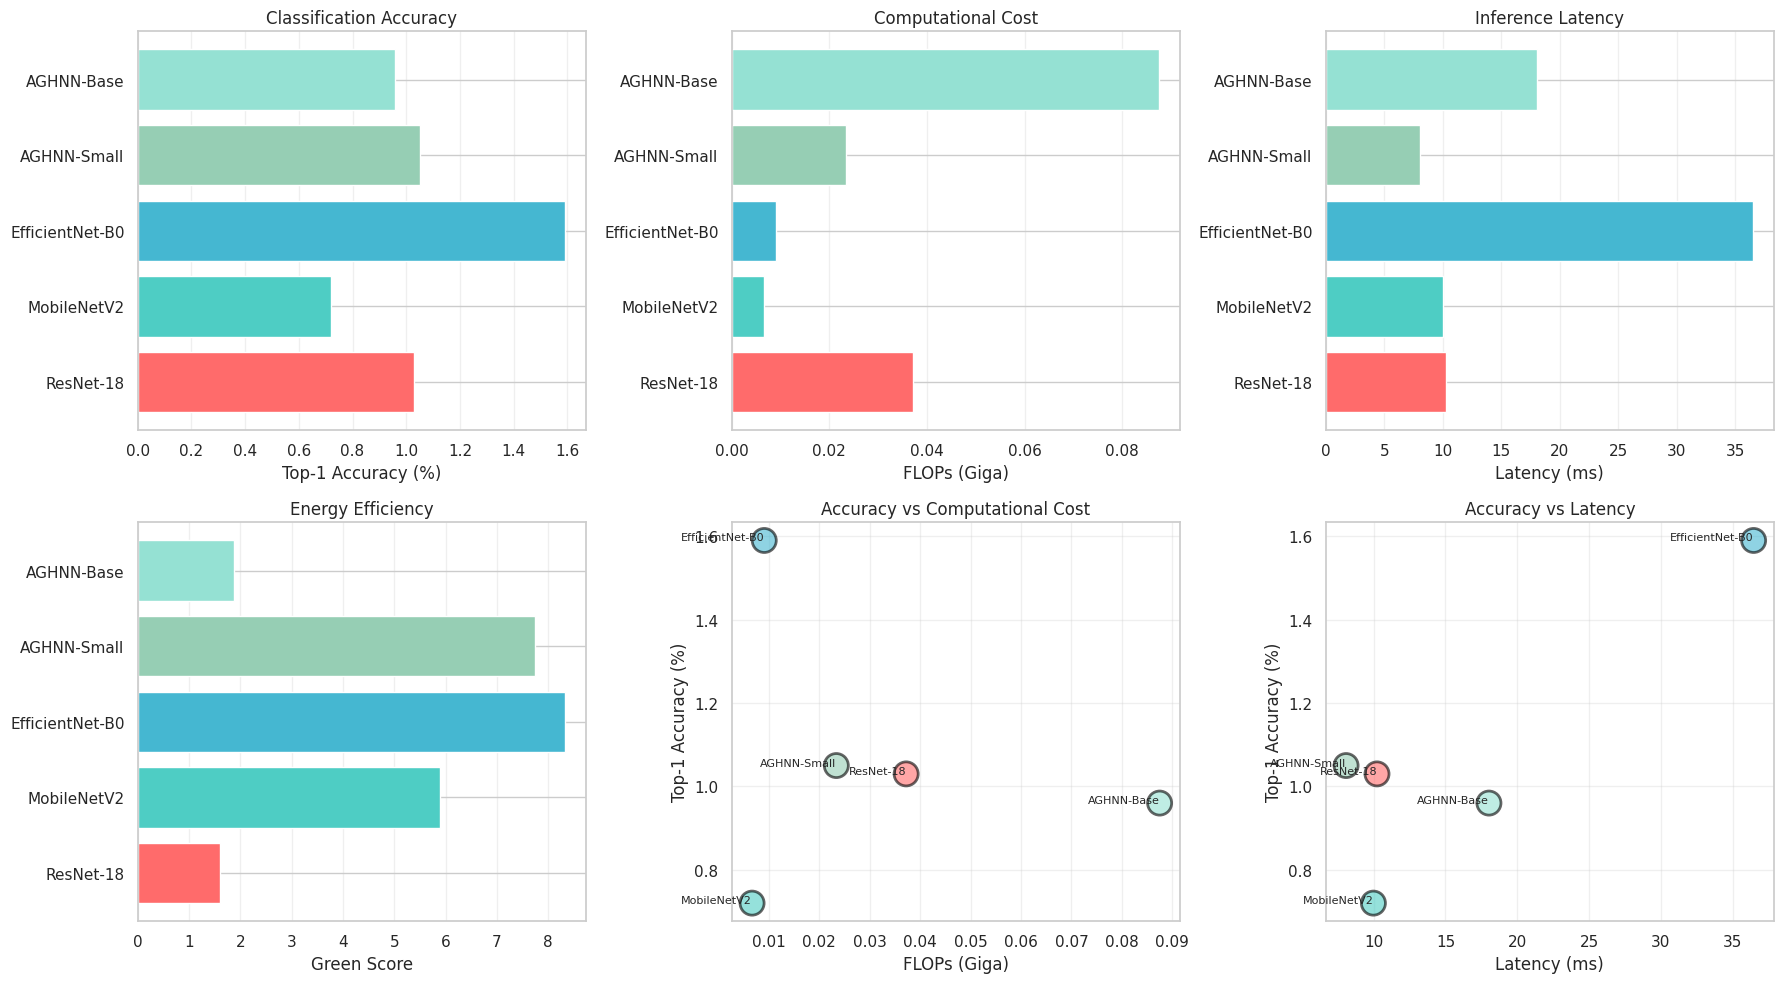

✓ Saved figure to /content/drive/MyDrive/Colab_Notebooks/Dissertation/evaluation_results/baseline_comparison_results.png


In [48]:
# Visualize baseline results
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#95E1D3']

# Accuracy
axes[0, 0].barh(baseline_df['Model'], baseline_df['Top-1 Acc (%)'], color=colors)
axes[0, 0].set_xlabel('Top-1 Accuracy (%)')
axes[0, 0].set_title('Classification Accuracy')
axes[0, 0].grid(axis='x', alpha=0.3)

# FLOPs
axes[0, 1].barh(baseline_df['Model'], baseline_df['FLOPs (G)'], color=colors)
axes[0, 1].set_xlabel('FLOPs (Giga)')
axes[0, 1].set_title('Computational Cost')
axes[0, 1].grid(axis='x', alpha=0.3)

# Latency
axes[0, 2].barh(baseline_df['Model'], baseline_df['Latency (ms)'], color=colors)
axes[0, 2].set_xlabel('Latency (ms)')
axes[0, 2].set_title('Inference Latency')
axes[0, 2].grid(axis='x', alpha=0.3)

# Green Score
axes[1, 0].barh(baseline_df['Model'], baseline_df['Green Score'], color=colors)
axes[1, 0].set_xlabel('Green Score')
axes[1, 0].set_title('Energy Efficiency')
axes[1, 0].grid(axis='x', alpha=0.3)

# Accuracy vs FLOPs
axes[1, 1].scatter(baseline_df['FLOPs (G)'], baseline_df['Top-1 Acc (%)'],
                   s=300, c=colors, alpha=0.6, edgecolors='black', linewidth=2)
for i, txt in enumerate(baseline_df['Model']):
    axes[1, 1].annotate(txt, (baseline_df['FLOPs (G)'].iloc[i], baseline_df['Top-1 Acc (%)'].iloc[i]),
                       fontsize=8, ha='right')
axes[1, 1].set_xlabel('FLOPs (Giga)')
axes[1, 1].set_ylabel('Top-1 Accuracy (%)')
axes[1, 1].set_title('Accuracy vs Computational Cost')
axes[1, 1].grid(alpha=0.3)

# Accuracy vs Latency
axes[1, 2].scatter(baseline_df['Latency (ms)'], baseline_df['Top-1 Acc (%)'],
                   s=300, c=colors, alpha=0.6, edgecolors='black', linewidth=2)
for i, txt in enumerate(baseline_df['Model']):
    axes[1, 2].annotate(txt, (baseline_df['Latency (ms)'].iloc[i], baseline_df['Top-1 Acc (%)'].iloc[i]),
                       fontsize=8, ha='right')
axes[1, 2].set_xlabel('Latency (ms)')
axes[1, 2].set_ylabel('Top-1 Accuracy (%)')
axes[1, 2].set_title('Accuracy vs Latency')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
baseline_fig = OUTPUT_DIR / 'baseline_comparison_results.png'
plt.savefig(baseline_fig, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved figure to {baseline_fig}")

---
# ANALYSIS 3: AGENTIC ROUTING ANALYSIS

Demonstrates intelligent routing behavior

In [ ]:
@torch.no_grad()
def analyze_routing(model, val_loader, device, class_names=None, max_batches=100):
    """Analyze routing behavior"""
    model.eval()

    if class_names is None:
        class_names = globals().get('CLASS_NAMES')
    if class_names is None:
        num_classes = int(globals().get('NUM_CLASSES', 100))
        class_names = [f'class_{i}' for i in range(num_classes)]

    num_classes = len(class_names)

    all_complexity = []
    all_predictions = []
    all_targets = []
    all_correct = []
    routing_paths = []
    per_class_complexity = [[] for _ in range(num_classes)]
    per_class_accuracy = [0] * num_classes
    per_class_total = [0] * num_classes

    print("\n🔄 Analyzing routing behavior...")
    pbar = tqdm(val_loader, desc='Analyzing', leave=False, total=max_batches)

    threshold_easy = getattr(model, 'threshold_easy', 0.35)
    threshold_hard = getattr(model, 'threshold_hard', 0.65)

    for batch_idx, (images, targets) in enumerate(pbar):
        if batch_idx >= max_batches:
            break

        images, targets = images.to(device), targets.to(device)
        outputs = model(images, return_complexity=True, hard_routing=True)
        logits = outputs['logits'] if isinstance(outputs, dict) else outputs
        complexity = outputs.get('complexity', torch.zeros(images.size(0), device=device))

        probs = torch.softmax(logits, dim=1)
        _, preds = torch.max(probs, dim=1)
        correct = preds.eq(targets)

        for c in complexity.cpu().numpy():
            if c < threshold_easy:
                routing_paths.append('easy')
            elif c > threshold_hard:
                routing_paths.append('hard')
            else:
                routing_paths.append('medium')

        all_complexity.extend(complexity.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())
        all_correct.extend(correct.cpu().numpy())

        for c_idx in range(num_classes):
            mask = targets == c_idx
            if mask.sum() > 0:
                per_class_complexity[c_idx].extend(complexity[mask].cpu().numpy())
                per_class_accuracy[c_idx] += correct[mask].sum().item()
                per_class_total[c_idx] += mask.sum().item()

    pbar.close()

    return {
        'complexity': np.array(all_complexity),
        'predictions': np.array(all_predictions),
        'targets': np.array(all_targets),
        'correct': np.array(all_correct),
        'routing': np.array(routing_paths),
        'per_class_complexity': per_class_complexity,
        'per_class_accuracy': per_class_accuracy,
        'per_class_total': per_class_total,
        'class_names': class_names,
    }

print("✓ Routing analysis function defined")

✓ Routing analysis function defined


In [ ]:
# Load AGHNN model and run routing analysis
num_classes = int(globals().get('NUM_CLASSES', 100))
class_names = globals().get('CLASS_NAMES', [f'class_{i}' for i in range(num_classes)])
model_agentic = AGHNN_Small(num_classes=num_classes).to(DEVICE)

# Try loading checkpoint if available
checkpoint_path = PROJECT_ROOT / 'checkpoints' / 'best.pth'
if checkpoint_path.exists():
    try:
        ckpt = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
        if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
            model_agentic.load_state_dict(ckpt['model_state_dict'], strict=False)
        else:
            model_agentic.load_state_dict(ckpt, strict=False)
        print("✓ Loaded checkpoint")
    except Exception as e:
        print(f"⚠ Could not load checkpoint: {e}")
        print("  Using untrained model")
else:
    print("⚠ Checkpoint not found, using untrained model")

# Compatibility smoke check before full routing analysis
try:
    smoke_images, _ = next(iter(val_loader))
    smoke_images = smoke_images[:2].to(DEVICE)
    smoke_out = model_agentic(smoke_images, return_complexity=True, hard_routing=True)
    smoke_logits = smoke_out['logits'] if isinstance(smoke_out, dict) else smoke_out
    if smoke_logits.shape[1] != num_classes:
        raise RuntimeError(
            f"Checkpoint/model class mismatch: logits={smoke_logits.shape[1]}, expected={num_classes}"
        )
    print("✓ Checkpoint/runtime compatibility smoke test passed")
except Exception as e:
    raise RuntimeError(
        "Checkpoint/runtime compatibility check failed. "
        "Rerun setup and data cells, or retrain/checkpoint migrate before routing analysis. "
        f"Details: {e}"
    )

# Run analysis
routing_data = analyze_routing(model_agentic, val_loader, DEVICE, class_names=class_names, max_batches=50)

⚠ Could not load checkpoint: Error(s) in loading state_dict for AGHNN:
	size mismatch for easy_path.stage1.0.block.4.weight: copying a param with shape torch.Size([48, 32, 1, 1]) from checkpoint, the shape in current model is torch.Size([32, 32, 1, 1]).
	size mismatch for easy_path.stage1.0.block.5.weight: copying a param with shape torch.Size([48]) from checkpoint, the shape in current model is torch.Size([32]).
	size mismatch for easy_path.stage1.0.block.5.bias: copying a param with shape torch.Size([48]) from checkpoint, the shape in current model is torch.Size([32]).
	size mismatch for easy_path.stage1.0.block.5.running_mean: copying a param with shape torch.Size([48]) from checkpoint, the shape in current model is torch.Size([32]).
	size mismatch for easy_path.stage1.0.block.5.running_var: copying a param with shape torch.Size([48]) from checkpoint, the shape in current model is torch.Size([32]).
	size mismatch for easy_path.stage2.0.block.0.weight: copying a param with shape torc

Analyzing:   0%|          | 0/50 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [51]:
# Compute statistics
routing_counts = pd.Series(routing_data['routing']).value_counts()
total_samples = len(routing_data['routing'])

stats = {
    'total_samples': total_samples,
    'overall_accuracy': float(routing_data['correct'].mean() * 100),
    'routing_distribution': {
        'easy': int(routing_counts.get('easy', 0)),
        'medium': int(routing_counts.get('medium', 0)),
        'hard': int(routing_counts.get('hard', 0)),
    },
    'complexity_stats': {
        'mean': float(routing_data['complexity'].mean()),
        'std': float(routing_data['complexity'].std()),
        'min': float(routing_data['complexity'].min()),
        'max': float(routing_data['complexity'].max()),
    },
}

# Per-path accuracy
for path in ['easy', 'medium', 'hard']:
    mask = routing_data['routing'] == path
    if mask.sum() > 0:
        stats[f'{path}_accuracy'] = float(routing_data['correct'][mask].mean() * 100)

# Correlation
if len(routing_data['complexity']) > 1:
    correlation = float(np.corrcoef(routing_data['complexity'], routing_data['correct'])[0, 1])
    stats['complexity_correctness_correlation'] = correlation

print("\n" + "="*70)
print("ROUTING ANALYSIS RESULTS")
print("="*70)
print(f"\n📊 Overall Accuracy: {stats['overall_accuracy']:.2f}%")
print(f"\n🔀 Routing Distribution:")
print(f"   Easy:   {stats['routing_distribution']['easy']:6d} samples ({100*stats['routing_distribution']['easy']/total_samples:6.2f}%)")
print(f"   Medium: {stats['routing_distribution']['medium']:6d} samples ({100*stats['routing_distribution']['medium']/total_samples:6.2f}%)")
print(f"   Hard:   {stats['routing_distribution']['hard']:6d} samples ({100*stats['routing_distribution']['hard']/total_samples:6.2f}%)")
print(f"\n🎯 Per-Path Accuracy:")
for path in ['easy', 'medium', 'hard']:
    if f'{path}_accuracy' in stats:
        print(f"   {path.capitalize():8s}: {stats[f'{path}_accuracy']:6.2f}%")
if 'complexity_correctness_correlation' in stats:
    print(f"\n🔗 Complexity-Correctness Correlation: {stats['complexity_correctness_correlation']:.4f}")


ROUTING ANALYSIS RESULTS

📊 Overall Accuracy: 0.98%

🔀 Routing Distribution:
   Easy:        0 samples (  0.00%)
   Medium:   6400 samples (100.00%)
   Hard:        0 samples (  0.00%)

🎯 Per-Path Accuracy:
   Medium  :   0.98%

🔗 Complexity-Correctness Correlation: -0.0152


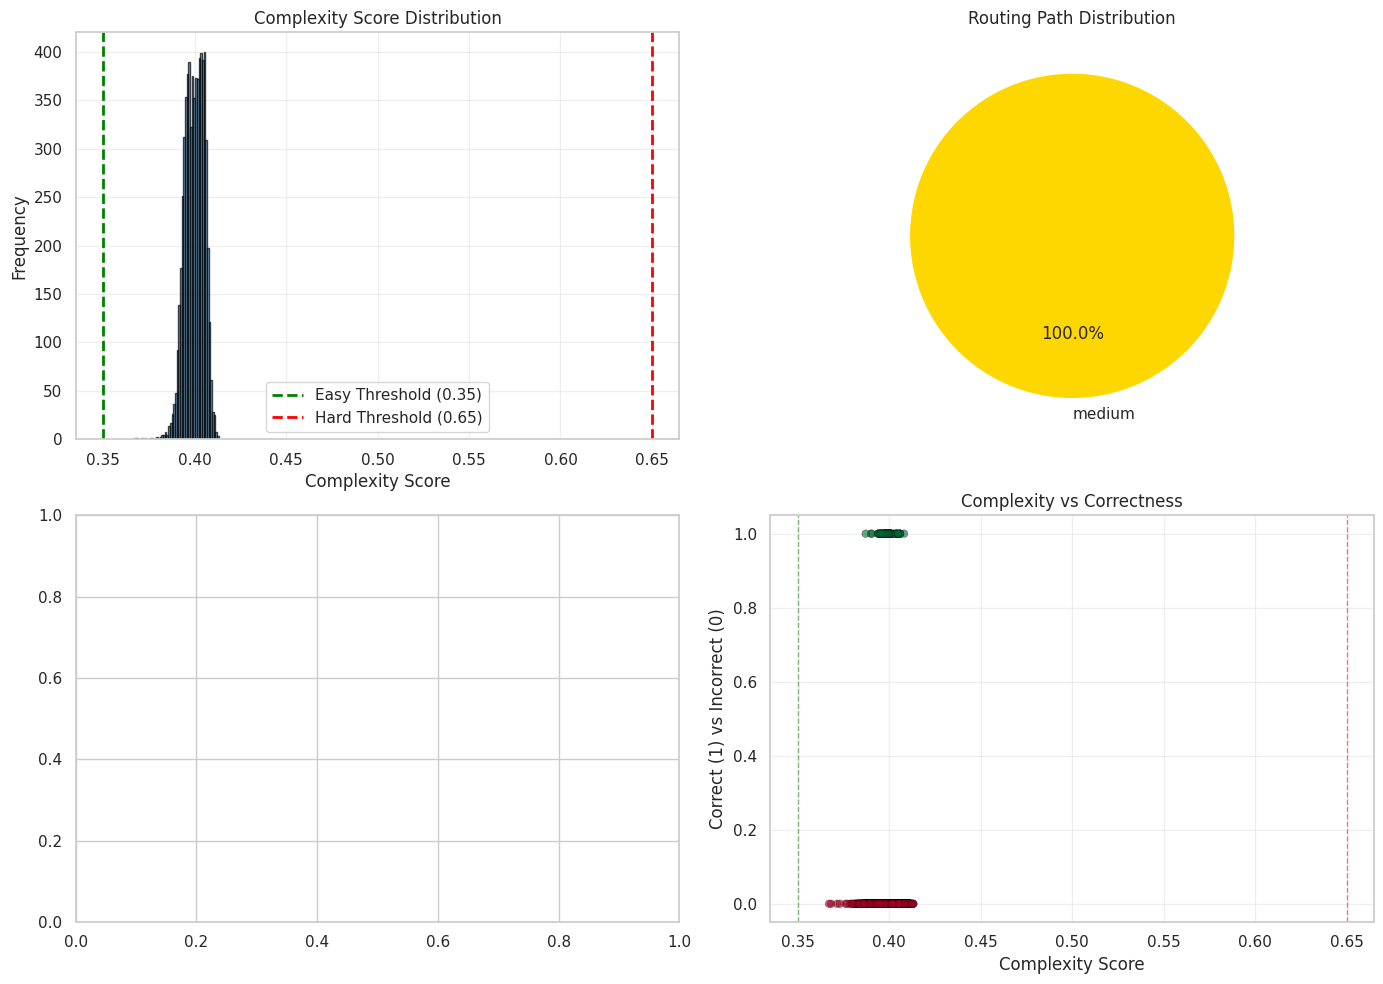

✓ Saved figure to /content/drive/MyDrive/Colab_Notebooks/Dissertation/evaluation_results/routing_analysis_distribution.png


In [52]:
# Visualize routing analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Complexity distribution
axes[0, 0].hist(routing_data['complexity'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 0].axvline(0.35, color='green', linestyle='--', linewidth=2, label='Easy Threshold (0.35)')
axes[0, 0].axvline(0.65, color='red', linestyle='--', linewidth=2, label='Hard Threshold (0.65)')
axes[0, 0].set_xlabel('Complexity Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Complexity Score Distribution')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Routing distribution pie
routing_counts = pd.Series(routing_data['routing']).value_counts()
colors_pie = {'easy': '#90EE90', 'medium': '#FFD700', 'hard': '#FF6B6B'}
pie_colors = [colors_pie.get(k, 'gray') for k in routing_counts.index]
axes[0, 1].pie(routing_counts.values, labels=routing_counts.index, colors=pie_colors,
               autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Routing Path Distribution')

# Per-path accuracy
if all(f'{p}_accuracy' in stats for p in ['easy', 'medium', 'hard']):
    paths = ['Easy', 'Medium', 'Hard']
    accs = [stats[f'{p.lower()}_accuracy'] for p in paths]
    colors_bar = ['#90EE90', '#FFD700', '#FF6B6B']
    bars = axes[1, 0].bar(paths, accs, color=colors_bar, edgecolor='black', alpha=0.8)
    axes[1, 0].set_ylabel('Accuracy (%)')
    axes[1, 0].set_title('Per-Path Accuracy')
    axes[1, 0].grid(axis='y', alpha=0.3)
    for bar, acc in zip(bars, accs):
        axes[1, 0].text(bar.get_x() + bar.get_width()/2, acc + 1, f'{acc:.2f}%',
                       ha='center', va='bottom', fontsize=10, fontweight='bold')

# Complexity vs Correctness
scatter = axes[1, 1].scatter(routing_data['complexity'], routing_data['correct'].astype(int),
                            c=routing_data['correct'].astype(int), cmap='RdYlGn',
                            s=30, alpha=0.6, edgecolors='black', linewidth=0.3)
axes[1, 1].axvline(0.35, color='green', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 1].axvline(0.65, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 1].set_xlabel('Complexity Score')
axes[1, 1].set_ylabel('Correct (1) vs Incorrect (0)')
axes[1, 1].set_title('Complexity vs Correctness')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
routing_fig = OUTPUT_DIR / 'routing_analysis_distribution.png'
plt.savefig(routing_fig, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved figure to {routing_fig}")

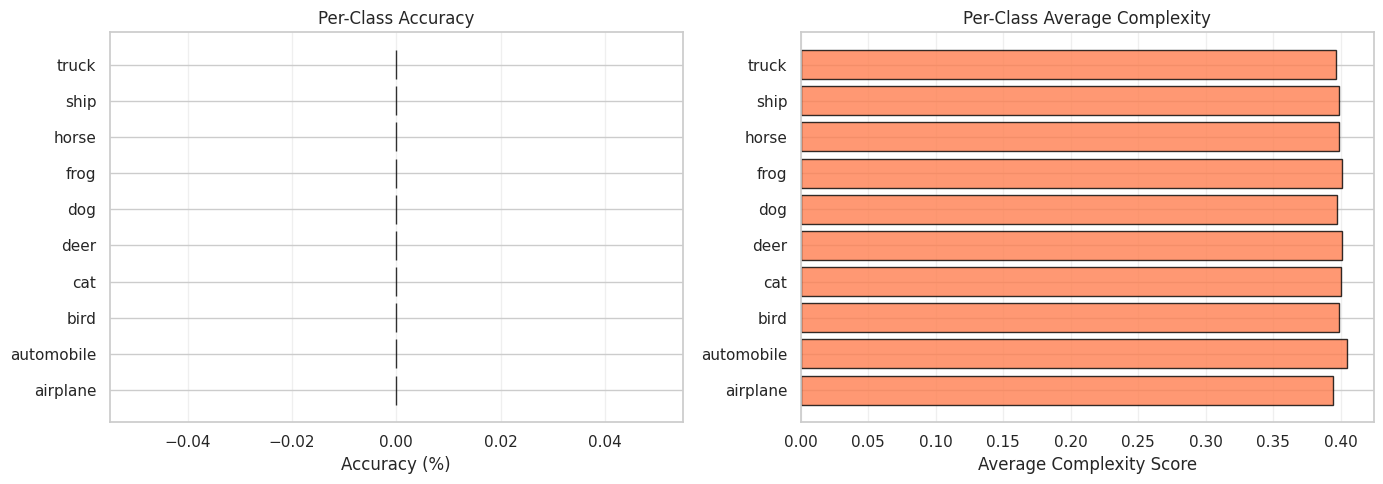

✓ Saved figure to /content/drive/MyDrive/Colab_Notebooks/Dissertation/evaluation_results/per_class_analysis.png


In [ ]:
# Per-class analysis
per_class_data = []
class_names = routing_data.get('class_names', globals().get('CLASS_NAMES', []))
num_classes = len(class_names)

for class_idx in range(num_classes):
    if routing_data['per_class_total'][class_idx] > 0:
        avg_complexity = float(np.mean(routing_data['per_class_complexity'][class_idx]))
        class_acc = routing_data['per_class_accuracy'][class_idx] / routing_data['per_class_total'][class_idx] * 100
        per_class_data.append({
            'class_name': class_names[class_idx],
            'avg_complexity': avg_complexity,
            'accuracy': class_acc,
            'samples': routing_data['per_class_total'][class_idx],
        })

per_class_df = pd.DataFrame(per_class_data)

# Visualize per-class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(per_class_df['class_name'], per_class_df['accuracy'],
             color='skyblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Accuracy (%)')
axes[0].set_title('Per-Class Accuracy')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(per_class_df['class_name'], per_class_df['avg_complexity'],
             color='coral', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Average Complexity Score')
axes[1].set_title('Per-Class Average Complexity')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
class_fig = OUTPUT_DIR / 'per_class_analysis.png'
plt.savefig(class_fig, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved figure to {class_fig}")

In [54]:
# Save statistics and per-sample data
stats_json = OUTPUT_DIR / 'routing_analysis_stats.json'
with open(stats_json, 'w') as f:
    json.dump(stats, f, indent=2)
print(f"✓ Saved stats to {stats_json}")

sample_df = pd.DataFrame({
    'complexity_score': routing_data['complexity'],
    'routing_path': routing_data['routing'],
    'prediction_correct': routing_data['correct'],
    'predicted_class': routing_data['predictions'],
    'true_class': routing_data['targets'],
})

sample_csv = OUTPUT_DIR / 'per_sample_routing_data.csv'
sample_df.to_csv(sample_csv, index=False)
print(f"✓ Saved per-sample data to {sample_csv}")

✓ Saved stats to /content/drive/MyDrive/Colab_Notebooks/Dissertation/evaluation_results/routing_analysis_stats.json
✓ Saved per-sample data to /content/drive/MyDrive/Colab_Notebooks/Dissertation/evaluation_results/per_sample_routing_data.csv


---
# SUMMARY: All Analyses Complete

In [55]:
print("\n" + "="*70)
print("✅ ALL ANALYSES COMPLETED")
print("="*70)

print("\n📁 Output Files Generated:")
print(f"\n📊 ABLATION STUDY:")
print(f"   CSV: evaluation_results/ablation_study_results.csv")
print(f"   PNG: evaluation_results/ablation_study_results.png")

print(f"\n📊 BASELINE COMPARISON:")
print(f"   CSV: evaluation_results/baseline_comparison_results.csv")
print(f"   PNG: evaluation_results/baseline_comparison_results.png")

print(f"\n📊 AGENTIC ROUTING ANALYSIS:")
print(f"   PNG1: evaluation_results/routing_analysis_distribution.png")
print(f"   PNG2: evaluation_results/per_class_analysis.png")
print(f"   JSON: evaluation_results/routing_analysis_stats.json")
print(f"   CSV: evaluation_results/per_sample_routing_data.csv")

print("\n💡 KEY METRICS:")
print(f"\n🔬 Ablation Results:")
print(ablation_df[['variant', 'top1_accuracy', 'improvement_vs_baseline', 'green_score']].to_string(index=False))

print(f"\n🏆 Baseline Results (Top 3):")
top3 = baseline_df.nlargest(3, 'Top-1 Acc (%)')
print(top3[['Model', 'Top-1 Acc (%)', 'FLOPs (G)', 'Green Score']].to_string(index=False))

print(f"\n🤖 Routing Analysis:")
print(f"   Overall Accuracy: {stats['overall_accuracy']:.2f}%")
if 'complexity_correctness_correlation' in stats:
    print(f"   Complexity-Correctness Correlation: {stats['complexity_correctness_correlation']:.3f}")
print(f"   Routing Distribution: Easy {stats['routing_distribution']['easy']:6d}, "
      f"Medium {stats['routing_distribution']['medium']:6d}, "
      f"Hard {stats['routing_distribution']['hard']:6d}")

print("\n" + "="*70)
print("✅ READY FOR VIVA PRESENTATION")
print("="*70)
print("\n📥 Download all files from evaluation_results/ folder")
print("📊 Use PNG figures in your presentation slides")
print("📈 Reference CSV tables for detailed metrics")
print("🎓 Good luck with your viva!")
print("="*70)


✅ ALL ANALYSES COMPLETED

📁 Output Files Generated:

📊 ABLATION STUDY:
   CSV: evaluation_results/ablation_study_results.csv
   PNG: evaluation_results/ablation_study_results.png

📊 BASELINE COMPARISON:
   CSV: evaluation_results/baseline_comparison_results.csv
   PNG: evaluation_results/baseline_comparison_results.png

📊 AGENTIC ROUTING ANALYSIS:
   PNG1: evaluation_results/routing_analysis_distribution.png
   PNG2: evaluation_results/per_class_analysis.png
   JSON: evaluation_results/routing_analysis_stats.json
   CSV: evaluation_results/per_sample_routing_data.csv

💡 KEY METRICS:

🔬 Ablation Results:
                             variant  top1_accuracy  improvement_vs_baseline  green_score
Baseline (No Routing, No Green Loss)          63.13                 0.000000   123.665348
                   +Adaptive Routing          63.13                 0.000000   123.665348
                    +Green Loss Only          62.86                -0.427689   123.136445
                          Fu